#  From Analog Superhet to Digital Downconversion (DDC)

---

## Part 1: The Analog Superheterodyne Receiver

Before discussing FPGAs, ADCs, or software, let's look at how analog radios solved the tuning problem for over 80 years.

### The Problem: Tuning (moving the signal frequency) vs. Filtering (moving the filter frequency)
Suppose you want to listen to an amateur radio voice transmission at **$7.100\text{ MHz}$**.
* A standard voice channel is only **$3\text{ kHz}$ wide** (spanning $7.100\text{ MHz}$ to $7.103\text{ MHz}$).
* Building an analog inductor-capacitor (LC) filter at $7.1\text{ MHz}$ that is only $3\text{ kHz}$ wide requires a Quality Factor ($Q = f / \Delta f$) of over $2{,}300$. That is physically impossible with practical LC components; temperature changes alone would drift the filter completely off-frequency.
* Even worse: if you want to tune across the band to $7.200\text{ MHz}$, you would need to adjust the components while keeping that razor-thin $3\text{ kHz}$ window intact.
* Edwin Armstrong solved this problem using the following trig identity.

---

### Deriving the Multiplier Math Using $\text{Re}(e^{j\theta})$
Analog receivers solve this by multiplying the incoming signal by a sine wave from a Local Oscillator (LO). 

What happens mathematically when two waves are multiplied? Instead of memorizing trig identities, we use **Euler’s identity**:
$$e^{j\theta} = \cos(\theta) + j\sin(\theta) \quad \implies \quad \cos(\theta) = \text{Re}\left\{e^{j\theta}\right\}$$

Now examine the product of two complex exponentials with opposite signs:
$$e^{j(a-b)} = e^{ja} \cdot e^{-jb}$$

Substitute Euler's formula into each term:
$$e^{j(a-b)} = \Big(\cos(a) + j\sin(a)\Big) \Big(\cos(b) - j\sin(b)\Big)$$
$$e^{j(a-b)} = \Big[\cos(a)\cos(b) + \sin(a)\sin(b)\Big] + j\Big[\sin(a)\cos(b) - \cos(a)\sin(b)\Big]$$

Taking the **real part** of both sides yields:
$$\cos(a - b) = \cos(a)\cos(b) + \sin(a)\sin(b) \quad \text{--- (Equation 1)}$$

Next, do the exact same thing for the sum $e^{j(a+b)} = e^{ja} \cdot e^{jb}$:
$$e^{j(a+b)} = \Big(\cos(a) + j\sin(a)\Big) \Big(\cos(b) + j\sin(b)\Big)$$
$$e^{j(a+b)} = \Big[\cos(a)\cos(b) - \sin(a)\sin(b)\Big] + j\Big[\sin(a)\cos(b) + \cos(a)\sin(b)\Big]$$

Taking the **real part** of both sides yields:
$$\cos(a + b) = \cos(a)\cos(b) - \sin(a)\sin(b) \quad \text{--- (Equation 2)}$$

Now, simply **add Equation 1 and Equation 2**:
$$\cos(a - b) + \cos(a + b) = 2\cos(a)\cos(b)$$

Divide by 2:
$$\cos(a)\cos(b) = \frac{1}{2}\cos(a - b) + \frac{1}{2}\cos(a + b)$$

#### The Physical Result:
Multiplying an RF signal ($f_{RF}$) with a Local Oscillator ($f_{LO}$) produces two new frequencies:
1. **Difference Frequency:** $|f_{RF} - f_{LO}|$
2. **Sum Frequency:** $f_{RF} + f_{LO}$

---

### The Single-Conversion Receiver & The Image Problem

Here is the correct signal flow. Notice that **the signal travels strictly left-to-right**. The Local Oscillator (LO) does *not* carry the signal; it simply feeds a reference sine wave into the multiplier:

```text
                         ┌───────────────┐
                         │     LO 1      │
                         │  (7.555 MHz)  │
                         └───────┬───────┘
                                 │ (Reference Sine)
                                 ▼
Antenna ──► [ RF Pre-BPF ] ──► [ × ] ──────► [ IF BPF ] ──────► [ Demodulator ] ──► Speaker
           (7.0 - 7.3 MHz)  Multiplier     (Fixed 455 kHz,
                                             3 kHz wide)
```

Suppose our Intermediate Frequency (**IF BPF**) is fixed at **$455\text{ kHz}$** with a $3\text{ kHz}$ bandwidth.
To hear our station at $f_{target} = 7{,}100\text{ kHz}$, we set our LO to:
$$f_{LO} = 7{,}100\text{ kHz} + 455\text{ kHz} = 7{,}555\text{ kHz}$$

The multiplier outputs the difference frequency:
$$|7{,}100 - 7{,}555| = 455\text{ kHz} \quad \longrightarrow \text{Passes through the 455 kHz IF filter!}$$

#### The Flaw (The Image):
What if an unwanted transmitter is broadcasting at **$8{,}010\text{ kHz}$**?
$$|8{,}010 - 7{,}555| = 455\text{ kHz} \quad \longrightarrow \text{Also passes right through the filter!}$$

Because $\cos(-\theta) = \cos(\theta)$, the real multiplier cannot tell whether the signal was above or below the LO. Both frequencies land at $455\text{ kHz}$ and scramble together.
* To prevent this, the **RF Pre-BPF** must attenuate $8{,}010\text{ kHz}$ *before* the multiplier.
* But $8{,}010\text{ kHz}$ is very close to $7{,}100\text{ kHz}$ (only $2 \times 455\text{ kHz} = 910\text{ kHz}$ away). A simple front-end filter cannot cleanly reject it without attenuating the desired band too.

---

### The Double-Conversion Receiver

To solve the image problem, analog engineers introduced a second conversion stage:

```text
                     ┌───────────────┐                    ┌───────────────┐
                     │     LO 1      │                    │     LO 2      │
                     │   (Tunable)   │                    │ (10.245 MHz)  │
                     └───────┬───────┘                    └───────┬───────┘
                             │                                    │
                             ▼                                    ▼
Antenna ──► [ RF BPF ] ──► [ × ] ──► [ 1st IF BPF ] ──────────► [ × ] ──► [ 2nd IF BPF ] ──► [ Demodulator ] ──► Speaker
          (1 - 30 MHz)    Mult 1    (High IF: 10.7 MHz,        Mult 2     (Low IF: 455 kHz,
                                    e.g., 50 kHz wide)                   sharp 3 kHz wide)
```

1. **Conversion 1 (High IF at 10.7 MHz):** The image frequency is located $2 \times 10.7\text{ MHz} = 21.4\text{ MHz}$ away from our desired station. A simple front-end filter can more easily eliminate it almost completely without attenuating the desired signal much at all.
2. **Conversion 2 (Low IF at 455 kHz):** Now that the image is gone, Multiplier 2 shifts the signal down to $455\text{ kHz}$, where a sharp, stable filter isolates just the **$3\text{ kHz}$ voice channel**.

---

## Part 2: Counter-Rotating Phasors & Why Cosines Cause Images

Why did the analog multiplier create an image in the first place? Because **a real cosine is not a single frequency**.

### The Intuition: Counter-Rotating Phasors
From Euler's identity:
$$e^{+j\omega t} = \cos(\omega t) + j\sin(\omega t)$$
$$e^{-j\omega t} = \cos(\omega t) - j\sin(\omega t)$$

If we add these two equations together, the imaginary terms cancel out:
$$e^{+j\omega t} + e^{-j\omega t} = 2\cos(\omega t) \quad \implies \quad \cos(\omega t) = \frac{1}{2}e^{+j\omega t} + \frac{1}{2}e^{-j\omega t}$$

Imagine looking at the complex plane:
* **$e^{+j\omega t}$** is an arrow of length $0.5$ rotating **Counter-Clockwise** at speed $+\omega$ (Positive Frequency).
* **$e^{-j\omega t}$** is an arrow of length $0.5$ rotating **Clockwise** at speed $-\omega$ (Negative Frequency).

```text
               +j (Imaginary)
                     ▲
                     │   e^(+jwt) [Counter-Clockwise]
                     │   ▲
                     │  /
                     │ /
                     │/
  ───────────────────┼───────────────────► Real
                     │\
                     │ \
                     │  \
                     │   ▼
                     │   e^(-jwt) [Clockwise]
                     ▼
```

As these two arrows rotate in opposite directions at the exact same rate:
1. Their vertical imaginary components ($+j\sin$ and $-j\sin$) are equal and opposite at every instant, so they **cancel to zero**.
2. Their horizontal real components ($\cos$) point in the identical direction and **add together**.

> **Crucial Takeaway:** A real cosine wave contains **two counter-rotating phasors at the same time** ($+\omega$ and $-\omega$). Because it contains both directions, multiplying by a real cosine shifts your radio signal in *both directions simultaneously*. That is what creates the image frequency!

---

### The Complex Multiplier: Shifting in ONE Direction Only
What happens if we multiply an RF signal by a **single complex exponential** $e^{-j\omega_{LO} t}$ instead of a cosine?
$$e^{+j\omega_{RF} t} \cdot e^{-j\omega_{LO} t} = e^{+j(\omega_{RF} - \omega_{LO}) t}$$

* There is only **one** rotating phasor.
* The frequency moves **strictly downward**.
* There is no counter-rotating partner, so **no sum term and no image frequency fold over!**

### Where do $I(t)$ and $Q(t)$ come from?
Our antenna captures a real voltage $x(t)$. How do we multiply a real antenna signal by $e^{-j\omega_{LO} t}$?
Using Euler's identity:
$$e^{-j\omega_{LO} t} = \cos(\omega_{LO} t) - j\sin(\omega_{LO} t)$$

Multiply $x(t)$ across both terms:
$$x(t) \cdot e^{-j\omega_{LO} t} = \underbrace{\Big[ x(t)\cos(\omega_{LO} t) \Big]}_{I(t)\text{ [In-Phase]}} \;+\; j \underbrace{\Big[ -x(t)\sin(\omega_{LO} t) \Big]}_{Q(t)\text{ [Quadrature]}}$$

* We split the antenna signal into two parallel paths.
* **$I(t)$ (In-Phase):** Multiplied by $\cos(\omega_{LO} t)$.
* **$Q(t)$ (Quadrature):** Multiplied by $-\sin(\omega_{LO} t)$ ($90^\circ$ phase-shifted).

Carrying the pair $(I, Q)$ gives us a true complex signal with **direction of rotation preserved**. Images are eliminated mathematically.

---

## Part 3: Python Demonstration of Counter-Rotating Phasors

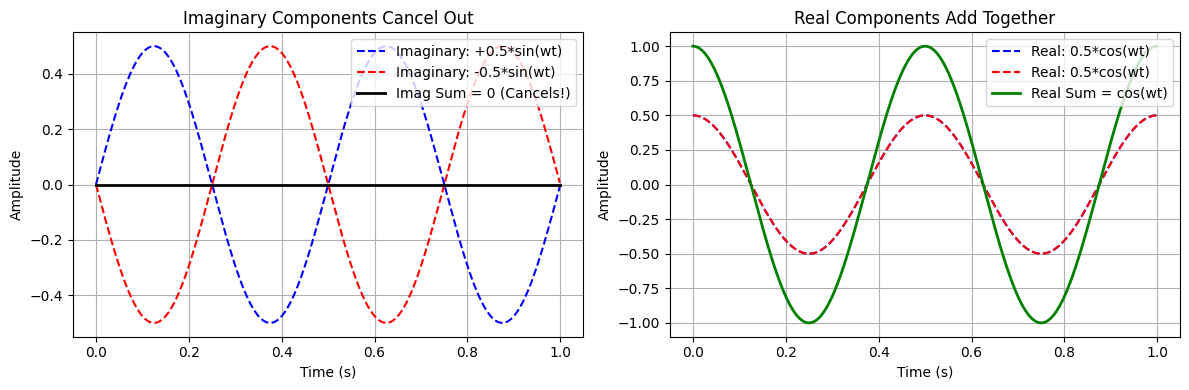

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generate time vector
fs_vis = 1000
t_vis = np.linspace(0, 1, fs_vis, endpoint=False)
f0 = 2  # 2 Hz rotation for clear visualization

# Two counter-rotating phasors
pos_phasor = 0.5 * np.exp(1j * 2 * np.pi * f0 * t_vis)   # Counter-clockwise (+2 Hz)
neg_phasor = 0.5 * np.exp(-1j * 2 * np.pi * f0 * t_vis)  # Clockwise (-2 Hz)
real_cosine = pos_phasor + neg_phasor                     # Sum = pure real cosine

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(t_vis, np.imag(pos_phasor), 'b--', label='Imaginary: +0.5*sin(wt)')
plt.plot(t_vis, np.imag(neg_phasor), 'r--', label='Imaginary: -0.5*sin(wt)')
plt.plot(t_vis, np.imag(real_cosine), 'k-', linewidth=2, label='Imag Sum = 0 (Cancels!)')
plt.title("Imaginary Components Cancel Out")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc='upper right')

plt.subplot(1, 2, 2)
plt.plot(t_vis, np.real(pos_phasor), 'b--', label='Real: 0.5*cos(wt)')
plt.plot(t_vis, np.real(neg_phasor), 'r--', label='Real: 0.5*cos(wt)')
plt.plot(t_vis, np.real(real_cosine), 'g-', linewidth=2, label='Real Sum = cos(wt)')
plt.title("Real Components Add Together")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

---

## Part 4: Your SDR Hardware Implementation

Here is how your specific hardware implements the double-conversion superhet using DSP:

```text
ANTENNA
   │
   ▼
┌──────────────┐
│  8-bit ADC   │  Direct RF Sampling @ 30.072 MSPS
└──────┬───────┘  Outputs signed 8-bit integers (-128 to +127)
       │
       │ Real 30.072 MSPS Stream x[n]
       │
┌──────┴────────────────────────────────────────────────────────────────────────┐
│ FPGA (1st Conversion to 48 kHz IF)                                            │
│                                                                               │
│                          cos(ω_LO · n)                                        │
│                       ┌─────────────────┐                                     │
│                       ▼                 │                                     │
│         ┌─────────► [ × ] ────────────► [ LPF ] ──► [ ÷626.5 ] ──► I          │
│         │          Mult I               │       (24 kHz)    Decimate  (48 kHz)│
│         │                               │                                     │
│  x[n] ──┤                        ┌──────┴──────┐                              │
│  (Real) │                        │ Digital NCO │                              │
│         │                        │ (Band Center│                              │
│         │                        └──────┬──────┘                              │
│         │                 -sin(ω_LO · n)│                                     │
│         │             ┌─────────────────┘                                     |
│         |             ▼                                                       |
│         └─────────► [ × ] ────────────► [ LPF ] ──► [ ÷626.5 ] ──► Q          │
│                    Mult Q               (24 kHz)    Decimate  (48 kHz)        │
│                                                                               │
└───────────────────────────────────────────────────────────────────────────────┘
                                         │
                            I2S Bus (Stereo 48 kHz)
                            Left Channel = I, Right Channel = Q
                                         │
                                         ▼
┌───────────────────────────────────────────────────────────────────────────────┐
│ RP2040 Microcontroller                                                        │
│                                                                               │
│   • PIO State Machine captures I2S stream at 48 kHz                           │
│   • USB CDC: Serial port for tuning commands from PC to FPGA                  │
│   • USB UAC1: Streams 48 kHz stereo IQ audio to PC as a standard USB Mic      │
└───────────────────────────────────────────────────────────────────────────────┘
                                         │
                                     USB Cable
                                         │
                                         ▼
┌───────────────────────────────────────────────────────────────────────────────┐
│ Host PC SDR Software (2nd Conversion to Audio Baseband)                       │
│                                                                               │
│                          cos(ω_IF · m)                                        │
│                       ┌─────────────────┐                                     │
│                       ▼                 │                                     │
│     I[m] ─────────► [ × ] ──────────────┼────────┐                            │
│                     Mult I              │        ▼                            │
│                                         │      [ + ] ──► [ 3 kHz Filter ]     |
│                                  ┌──────┴──────┐ ▲       (Isolates Target     |
│                                  │  PC 2nd LO  │ │        Voice Signal)       |
│                                  │             │ │             │              |
│                                  └──────┬──────┘ │             ▼              |
│                                         │        │      [ Demodulator ]       |
│                          sin(ω_IF · m)  │        │             │              |
│                       ┌─────────────────┘        │             ▼              |
|                       ▼                          |                            | 
│     Q[m] ─────────► [ × ] ───────────────────────┘          Speakers          │
│                     Mult Q                                                    │
│                                                                               │
│     (In complex notation: y[m] = (I[m] + j·Q[m]) · e^(-j · ω_IF · m) )        │
└───────────────────────────────────────────────────────────────────────────────┘
```

---

### Step-by-Step Breakdown

#### 1. The 8-bit ADC @ 30.072 MHz
* The ADC directly samples the antenna voltage, generating signed 8-bit integers ($-128$ to $+127$).
* Nyquist Bandwidth: $\frac{30.072\text{ MHz}}{2} = 15.036\text{ MHz}$. The radio directly captures everything from DC up to $15\text{ MHz}$ without any analog mixer.

#### 2. The FPGA (1st Conversion)
* The FPGA's **Numerically Controlled Oscillator (NCO)** generates $\cos(\omega_{LO} n)$ and $-\sin(\omega_{LO} n)$ tuned to the center of the band of interest.
* Two multipliers create parallel **In-Phase ($I$)** and **Quadrature ($Q$)** data streams.
* This brings a **$48\text{ kHz}$ wide swath** of RF spectrum down to DC ($0\text{ Hz}$), spanning from **$-24\text{ kHz}$ to $+24\text{ kHz}$**.
* Somewhere inside this $48\text{ kHz}$ swath sits our desired **$3\text{ kHz}$ voice signal**.

#### 3. What is Decimation? (LPF + Downsampling)
Our ADC runs at **$30.072\text{ MHz}$**, but our USB audio link needs **$48\text{ kHz}$**.
The decimation factor is:
$$R = \frac{30{,}072{,}000\text{ Hz}}{48{,}000\text{ Hz}} = 626.5$$

* **Why can't you just throw away 625 out of every 626 samples?**
  High frequencies masquerade as low frequencies when sample rates drop. Without filtering, the entire $30\text{ MHz}$ worth of noise and strong broadcast stations will fold into the $48\text{ kHz}$ band, burying your station.
* **The Rule of Decimation:**
  $$\textbf{Decimation} \;=\; \textbf{Low-Pass Filter (LPF)} \;+\; \textbf{Downsampling}$$
  The FPGA applies a steep digital filter with a cutoff at $24\text{ kHz}$ to eliminate everything outside $[-24\text{ kHz}, +24\text{ kHz}]$. Once filtered, it safely drops the sample rate to $48\text{ kSPS}$.

#### 4. The RP2040 Microcontroller
* The RP2040 uses its **Programmable I/O (PIO)** state machines to clock in the stereo I2S stream (Left = $I$, Right = $Q$).
* It packages the data into two standard USB interfaces:
  * **USB CDC:** Virtual COM port used to send frequency tuning commands from the PC to the FPGA.
  * **USB UAC1 (Audio Class 1):** Delivers the $48\text{ kSPS}$ stereo IQ stream to the PC as a driverless USB microphone.

#### 5. The Host PC (2nd Conversion)
The PC acts as the **second conversion stage**:
* The FPGA brought a $48\text{ kHz}$ swath down to DC.
* Your target $3\text{ kHz}$ voice transmission might sit at $+12\text{ kHz}$ inside that swath.
* The PC software multiplies $(I + jQ)$ by $e^{-j 2\pi f_{IF} t}$ (where $f_{IF} = +12\text{ kHz}$). This shifts the target station to $0\text{ Hz}$.
* A final sharp **$3\text{ kHz}$ digital low-pass filter** removes the rest of the $48\text{ kHz}$ band.
* The demodulator extracts the audio and sends it to your speakers.

---

## Part 5: Python Simulation of the Second Conversion Which Happens in the PC SDR Software

In [6]:
%pip install scipy  # This is only needed if you don't have scipy in your venv.


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: /home/frohro/.local/share/pipx/venvs/jupyterlab/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


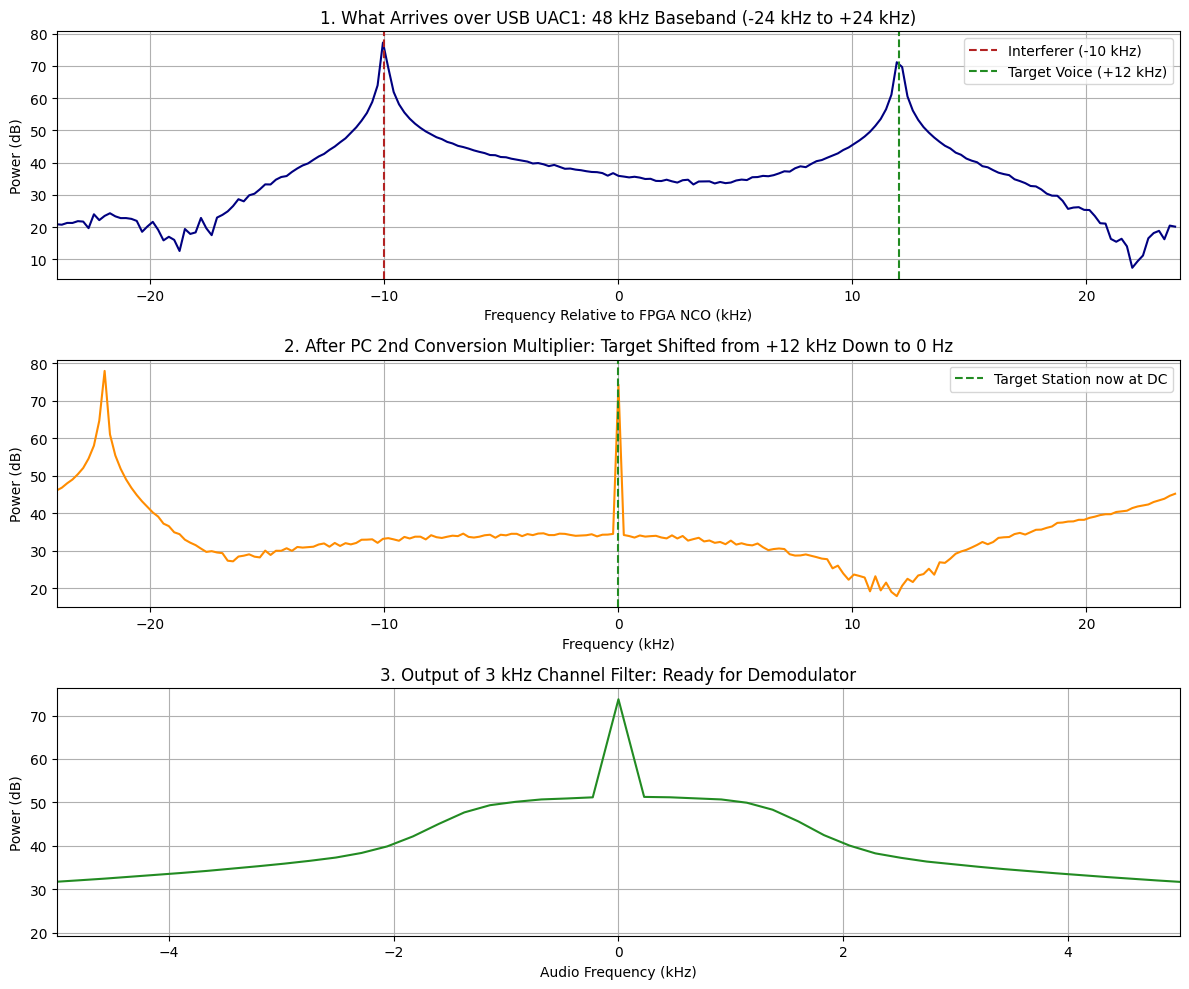

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# --- 1. RF Environment & 8-bit ADC Simulation ---
fs_adc = 30.072e6            # 30.072 MHz ADC clock
N = 131072                   # Number of ADC samples
t_adc = np.arange(N) / fs_adc

# Center of our band of interest: 7.100 MHz
# Target 3 kHz voice station: 7.112 MHz (+12 kHz from band center)
# Strong interferer: 7.090 MHz (-10 kHz from band center)
f_target = 7.112e6
f_interferer = 7.090e6

# Antenna analog voltage
rf_analog = (
    0.5 * np.cos(2 * np.pi * f_target * t_adc) + 
    0.8 * np.cos(2 * np.pi * f_interferer * t_adc) +
    0.05 * np.random.randn(N)
)

# 8-bit ADC Quantization (-128 to +127)
rf_8bit = np.clip(np.round(rf_analog * 100), -128, 127).astype(np.int8)

# --- 2. FPGA DDC (1st Conversion) ---
# NCO set to 7.100 MHz
f_nco = 7.100e6
nco_phase = 2 * np.pi * f_nco * t_adc
lo_I = np.cos(nco_phase)
lo_Q = -np.sin(nco_phase)

# Parallel Multipliers
I_mult = rf_8bit * lo_I
Q_mult = rf_8bit * lo_Q

# Anti-Aliasing LPF (Cutoff at 24 kHz)
nyq_adc = fs_adc / 2
lpf_b, lpf_a = signal.butter(4, 24e3 / nyq_adc, btype='low')
I_filtered = signal.lfilter(lpf_b, lpf_a, I_mult)
Q_filtered = signal.lfilter(lpf_b, lpf_a, Q_mult)

# Decimate down to 48 kSPS
dec_rate = int(fs_adc / 48e3)
I_48k = I_filtered[::dec_rate]
Q_48k = Q_filtered[::dec_rate]
fs_audio = fs_adc / dec_rate
t_audio = np.arange(len(I_48k)) / fs_audio

# Complex baseband signal entering PC via USB UAC1
iq_data = I_48k + 1j * Q_48k

# --- 3. Host PC Software (2nd Conversion) ---
# User clicks on the +12 kHz voice station
# PC 2nd LO shifts +12 kHz down to 0 Hz
f_2nd_lo = 12e3
pc_lo = np.exp(-1j * 2 * np.pi * f_2nd_lo * t_audio)
shifted_baseband = iq_data * pc_lo

# Sharp 3 kHz Channel Filter
nyq_audio = fs_audio / 2
chan_b, chan_a = signal.butter(4, (3e3 / 2) / nyq_audio, btype='low')
final_audio = signal.lfilter(chan_b, chan_a, shifted_baseband)

# --- 4. Spectra Visualizations ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# 1. 48 kHz Baseband spectrum from RP2040
freqs_48k = np.fft.fftshift(np.fft.fftfreq(len(iq_data), 1/fs_audio))
spec_48k = 20 * np.log10(np.abs(np.fft.fftshift(np.fft.fft(iq_data))) + 1e-3)
axes[0].plot(freqs_48k / 1e3, spec_48k, color='navy')
axes[0].set_title("1. What Arrives over USB UAC1: 48 kHz Baseband (-24 kHz to +24 kHz)")
axes[0].set_xlabel("Frequency Relative to FPGA NCO (kHz)")
axes[0].set_ylabel("Power (dB)")
axes[0].axvline(-10, color='firebrick', linestyle='--', label="Interferer (-10 kHz)")
axes[0].axvline(+12, color='forestgreen', linestyle='--', label="Target Voice (+12 kHz)")
axes[0].set_xlim(-24, 24)
axes[0].grid(True)
axes[0].legend()

# 2. Spectrum after PC 2nd Conversion
spec_pc = 20 * np.log10(np.abs(np.fft.fftshift(np.fft.fft(shifted_baseband))) + 1e-3)
axes[1].plot(freqs_48k / 1e3, spec_pc, color='darkorange')
axes[1].set_title("2. After PC 2nd Conversion Multiplier: Target Shifted from +12 kHz Down to 0 Hz")
axes[1].set_xlabel("Frequency (kHz)")
axes[1].set_ylabel("Power (dB)")
axes[1].axvline(0, color='forestgreen', linestyle='--', label="Target Station now at DC")
axes[1].set_xlim(-24, 24)
axes[1].grid(True)
axes[1].legend()

# 3. Spectrum after 3 kHz Channel Filter
spec_final = 20 * np.log10(np.abs(np.fft.fftshift(np.fft.fft(final_audio))) + 1e-3)
axes[2].plot(freqs_48k / 1e3, spec_final, color='forestgreen')
axes[2].set_title("3. Output of 3 kHz Channel Filter: Ready for Demodulator")
axes[2].set_xlabel("Audio Frequency (kHz)")
axes[2].set_ylabel("Power (dB)")
axes[2].set_xlim(-5, 5)
axes[2].grid(True)

plt.tight_layout()
plt.show()

---

## Part 6: Architecture Comparison

| Stage | Analog Double-Conversion Superhet | Our FPGA + RP2040 DDC System |
| :--- | :--- | :--- |
| **RF Input** | Continuous antenna voltage | **8-bit ADC** directly sampling @ **$30.072\text{ MSPS}$** |
| **1st LO** | Tunable analog LC / Synthesizer VFO | Digital **NCO** generating $\cos(\omega_{LO} n)$ and $-\sin(\omega_{LO} n)$ |
| **1st Multiplier** | Diode ring mixer | FPGA hardware multipliers producing $I$ and $Q$ |
| **1st IF Filter** | Fixed 10.7 MHz crystal filter | FPGA **Anti-Aliasing LPF + Decimator** down to $48\text{ kSPS}$ |
| **Data Link** | Coaxial cable between IF stages | **I2S Bus** $\to$ **RP2040** $\to$ **USB UAC1** |
| **2nd Conversion** | Fixed Multiplier to 455 kHz | PC software multiplier ($e^{-j 2\pi f_{IF} t}$) across $\pm 24\text{ kHz}$ |
| **Channel Filter** | Sharp 3 kHz crystal/mechanical filter | PC digital low-pass filter ($3\text{ kHz}$ wide) |
| **Demodulator** | Analog detector circuit | PC software demodulator |